In [15]:
import torch
import numpy as np

In [16]:
from torchvision import datasets
import torchvision.transforms as transforms

# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 20

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and test datasets
train_data = datasets.MNIST(root='../data', train=True,
                                   download=True, transform=transform)
test_data = datasets.MNIST(root='../data', train=False,
                                  download=True, transform=transform)

# prepare data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

100.0%
100.0%
100.0%
100.0%


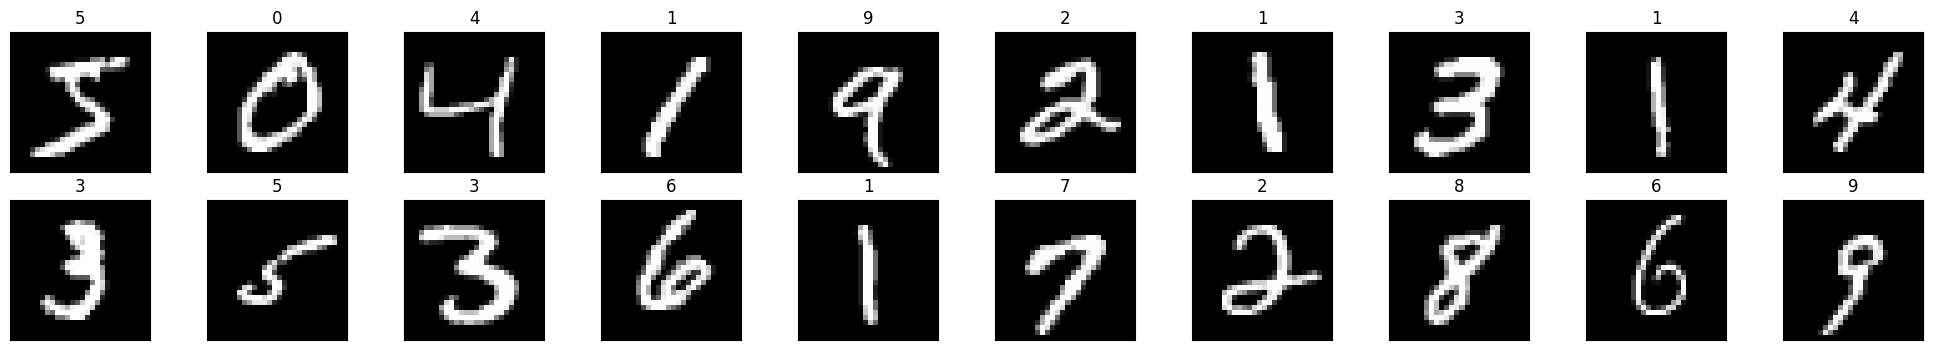

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline
    
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

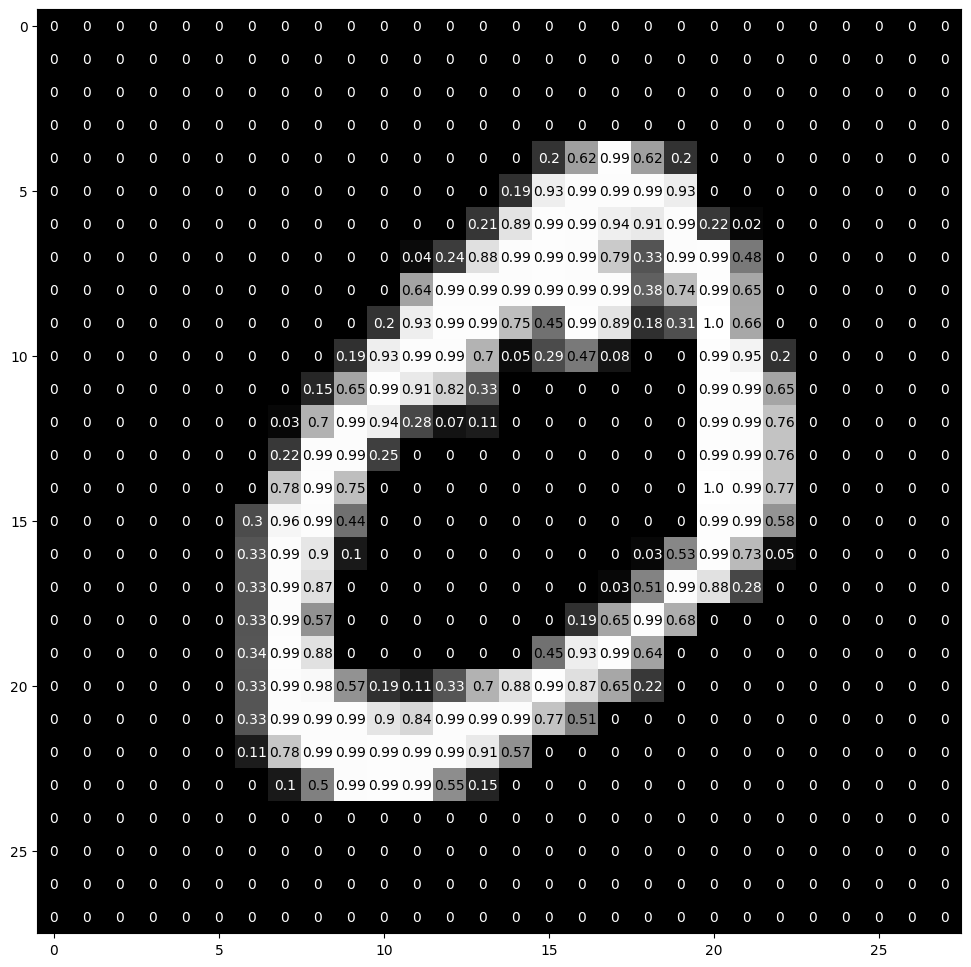

In [20]:
img = np.squeeze(images[1])

fig = plt.figure(figsize = (12,12)) 
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

In [21]:
import torch.nn as nn
import torch.nn.functional as F

## TODO: Define the NN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # linear layer (784 -> 1 hidden node)
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        # flatten image input
        x = x.view(-1, 28 * 28)
        # add hidden layer, with relu activation function
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

# initialize the NN
model = Net()
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [22]:
## TODO: Specify loss and optimization functions

# specify loss function
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [23]:
# number of epochs to train the model
n_epochs = 30  # suggest training between 20-50 epochs

model.train() # prep model for training

for epoch in range(n_epochs):
    # monitor training loss
    train_loss = 0.0
    
    ###################
    # train the model #
    ###################
    for data, target in train_loader:
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update running training loss
        train_loss += loss.item()*data.size(0)
        
    # print training statistics 
    # calculate average loss over an epoch
    train_loss = train_loss/len(train_loader.dataset)

    print('Epoch: {} \tTraining Loss: {:.6f}'.format(
        epoch+1, 
        train_loss
        ))

Epoch: 1 	Training Loss: 0.833164
Epoch: 2 	Training Loss: 0.321454
Epoch: 3 	Training Loss: 0.249323
Epoch: 4 	Training Loss: 0.200414
Epoch: 5 	Training Loss: 0.169028
Epoch: 6 	Training Loss: 0.146919
Epoch: 7 	Training Loss: 0.129080
Epoch: 8 	Training Loss: 0.114028
Epoch: 9 	Training Loss: 0.103386
Epoch: 10 	Training Loss: 0.093051
Epoch: 11 	Training Loss: 0.085918
Epoch: 12 	Training Loss: 0.079084
Epoch: 13 	Training Loss: 0.073757
Epoch: 14 	Training Loss: 0.068984
Epoch: 15 	Training Loss: 0.062654
Epoch: 16 	Training Loss: 0.059574
Epoch: 17 	Training Loss: 0.055789
Epoch: 18 	Training Loss: 0.052553
Epoch: 19 	Training Loss: 0.050120
Epoch: 20 	Training Loss: 0.047081
Epoch: 21 	Training Loss: 0.043562
Epoch: 22 	Training Loss: 0.040819
Epoch: 23 	Training Loss: 0.038758
Epoch: 24 	Training Loss: 0.037266
Epoch: 25 	Training Loss: 0.035391
Epoch: 26 	Training Loss: 0.032611
Epoch: 27 	Training Loss: 0.031362
Epoch: 28 	Training Loss: 0.029545
Epoch: 29 	Training Loss: 0.0

In [24]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for *evaluation*

for data, target in test_loader:
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(data)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# calculate and print avg test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            str(i), 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.059234

Test Accuracy of     0: 99% (971/980)
Test Accuracy of     1: 99% (1127/1135)
Test Accuracy of     2: 97% (1011/1032)
Test Accuracy of     3: 97% (987/1010)
Test Accuracy of     4: 98% (971/982)
Test Accuracy of     5: 98% (879/892)
Test Accuracy of     6: 98% (939/958)
Test Accuracy of     7: 98% (1009/1028)
Test Accuracy of     8: 96% (944/974)
Test Accuracy of     9: 97% (981/1009)

Test Accuracy (Overall): 98% (9819/10000)


Overall accuracy (from confusion matrix): 0.9819


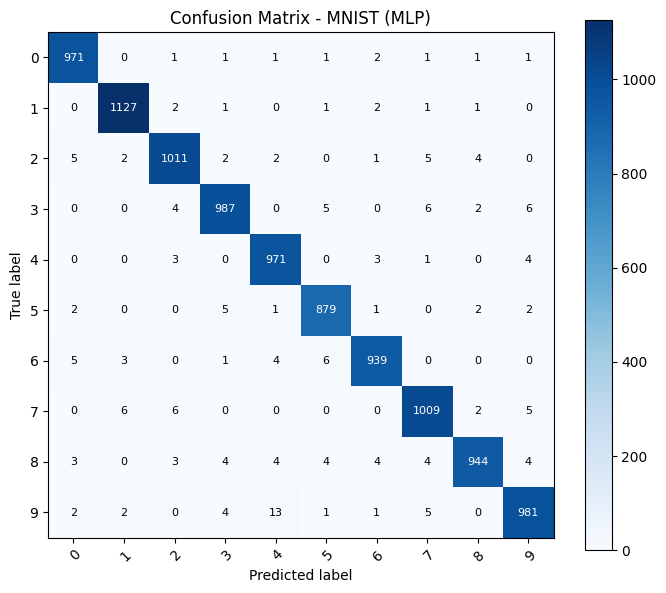

In [29]:
# Confusion Matrix (10x10) untuk MNIST
import numpy as np
import matplotlib.pyplot as plt

model.eval()
cm = np.zeros((10, 10), dtype=np.int64)

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        _, pred = torch.max(output, 1)

        t = target.detach().cpu().numpy()
        p = pred.detach().cpu().numpy()
        for true_label, pred_label in zip(t, p):
            cm[true_label, pred_label] += 1

# Visualisasi confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(10),
    yticks=np.arange(10),
    xlabel='Predicted label',
    ylabel='True label',
    title='Confusion Matrix - MNIST (MLP)',
)
ax.set_xticklabels([str(i) for i in range(10)])
ax.set_yticklabels([str(i) for i in range(10)])
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Tampilkan angka di setiap sel
thresh = cm.max() / 2.0 if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, int(cm[i, j]),
            ha='center', va='center',
            color='white' if cm[i, j] > thresh else 'black',
            fontsize=8,
        )

# Ringkasan akurasi dari confusion matrix
acc_cm = np.trace(cm) / np.sum(cm) if np.sum(cm) > 0 else 0.0
print(f"Overall accuracy (from confusion matrix): {acc_cm:.4f}")

plt.tight_layout()
plt.show()

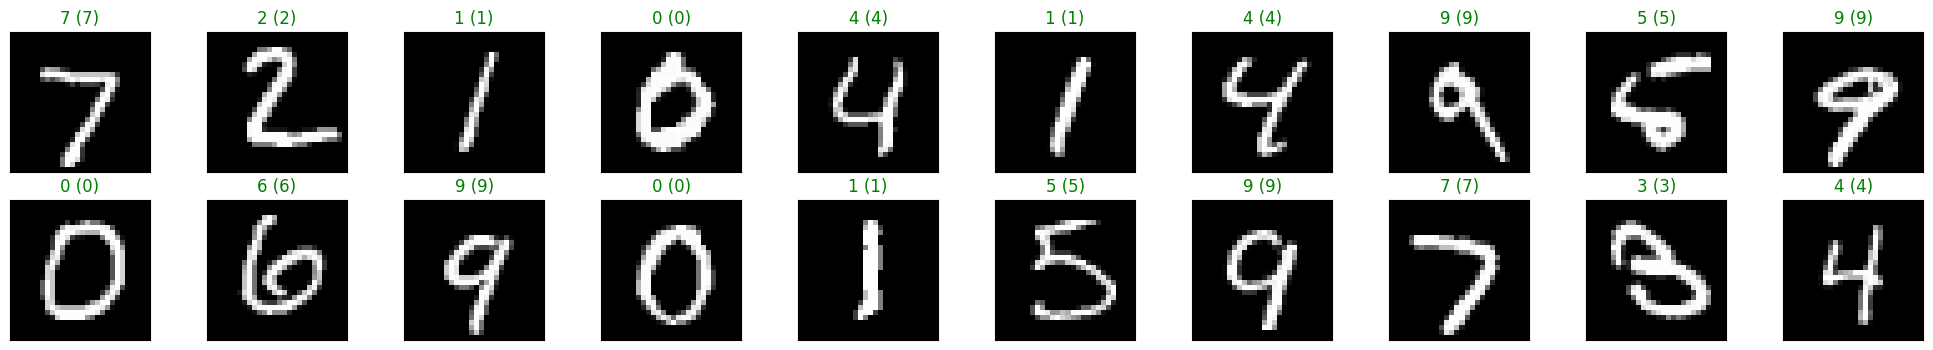

In [27]:
# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
# prep images for display
images = images.numpy()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))